# Klasifikasi Risiko Serangan Jantung Menggunakan Random Forest: Analisis Data Pasien untuk Deteksi Dini



## Pendahuluan

Penyakit jantung merupakan salah satu penyebab utama kematian di Indonesia, dengan prevalensi sebesar 0,85% pada tahun 2023 dan jumlah kematian mencapai sekitar 650.000 jiwa per tahun. Menurut BPJS Kesehatan, pengeluaran untuk penyakit jantung bahkan mencapai Rp 23,5 triliun di tahun yang sama, menjadikannya beban ekonomi tertinggi di sektor kesehatan. Faktor risiko seperti merokok, obesitas, tekanan darah tinggi, dan gaya hidup tidak sehat membuat deteksi dini sangat penting untuk mencegah komplikasi serius.

Seiring berkembangnya data dan teknologi, metode machine learning semakin banyak digunakan dalam bidang kesehatan, khususnya untuk klasifikasi penyakit. Salah satu algoritma yang terbukti efektif adalah Random Forest, yang mampu menghasilkan prediksi cepat dan akurat. Proyek ini bertujuan untuk membangun model prediksi risiko serangan jantung sebagai alat bantu dalam pengambilan keputusan medis secara preventif.

Tujuan dari analisis ini sebagai berikut:


*   Mengidentifikasi individu yang memiliki risiko tinggi terhadap serangan jantung.
*   Membangun model klasifikasi berbasis Random Forest untuk prediksi risiko.
*   Mengevaluasi performa model berdasarkan metrik akurasi, precision, recall, dan AUC.



## Deskripsi Dataset

Dataset yang digunakan dalam analisis ini berasal dari Kaggle dengan judul **Heart Attack Prediction in Indonesia**. Dataset ini berisi informasi kesehatan dan demografi pasien yang digunakan untuk memprediksi risiko serangan jantung. Data mencakup berbagai fitur seperti usia, jenis kelamin, tekanan darah, kadar kolesterol, kadar gula darah, dan beberapa indikator medis lainnya.

### 📌 Informasi Umum

- **Nama Dataset:** Heart Attack Prediction in Indonesia
- **Sumber Data:** [Kaggle - Heart Attack Prediction in Indonesia](https://www.kaggle.com/datasets/ankushpanday2/heart-attack-prediction-in-indonesia)  
- **Jumlah Entri:** 158.355 baris
- **Ukuran File:** 20.75 MB

## Tahapan Analisis

Analisis dilakukan secara bertahap, dimulai dari pemuatan dan pemeriksaan data, eksplorasi data secara visual, preprocessing, pelatihan model klasifikasi menggunakan algoritma Random Forest, hingga evaluasi dan visualisasi hasil prediksi. Setiap langkah dirancang untuk memastikan data dalam kondisi siap pakai, model bekerja optimal, dan hasil akhir dapat diinterpretasikan dengan jelas.

Langkah-langkahnya dijabarkan sebagai berikut:


### BAGIAN 1: PENGATURAN AWAL DAN IMPOR LIBRARY

Mempersiapkan semua library yang diperlukan untuk proses analisis, mulai dari pemrosesan data, visualisasi, hingga pembuatan dan evaluasi model machine learning. Selain itu, dilakukan juga pengaturan tampilan grafik dan pengabaian peringatan agar output lebih bersih.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import warnings

# Mengabaikan peringatan agar output lebih bersih
warnings.filterwarnings('ignore')
# Mengatur gaya visualisasi default untuk semua plot
sns.set_style('whitegrid')

### BAGIAN 2: MEMUAT DAN MEMERIKSA DATA

Pada tahap ini, dataset dimuat dari file CSV dan dilakukan pemeriksaan awal untuk memahami struktur data. Pemeriksaan mencakup penampilan beberapa baris pertama serta informasi umum seperti jumlah entri, tipe data setiap kolom, dan nilai non-null. Langkah ini penting untuk memastikan bahwa data terbaca dengan baik dan siap diproses lebih lanjut.


In [5]:
# Memuat dataset dari file CSV
df = pd.read_csv ('heart_attack_prediction_indonesia.csv')
df

print("\nBagian 2: Memuat dan Memeriksa Data")
print("-----------------------------------------")
print("5 Baris Pertama Data:")
print(df.head())
print("\nInformasi Umum Dataset:")
df.info()


Bagian 2: Memuat dan Memeriksa Data
-----------------------------------------
5 Baris Pertama Data:
   age  gender region income_level  hypertension  diabetes  cholesterol_level  \
0   60    Male  Rural       Middle             0         1                211   
1   53  Female  Urban          Low             0         0                208   
2   62  Female  Urban          Low             0         0                231   
3   73    Male  Urban          Low             1         0                202   
4   52    Male  Urban       Middle             1         0                232   

   obesity  waist_circumference  family_history  ... blood_pressure_diastolic  \
0        0                   83               0  ...                       62   
1        0                  106               1  ...                       76   
2        1                  112               1  ...                       74   
3        0                   82               1  ...                       65   
4      

### BAGIAN 3: EKSPLORASI DATA (EXPLORATORY DATA ANALYSIS - EDA)

Tahap ini bertujuan untuk memahami distribusi data dan karakteristik variabel yang tersedia. Salah satu langkah awal dalam EDA adalah melihat distribusi variabel target (`heart_attack`) untuk mengetahui proporsi antara individu yang berisiko dan tidak berisiko mengalami serangan jantung. Visualisasi ini membantu dalam mengenali potensi ketidakseimbangan kelas yang dapat mempengaruhi performa model.



Bagian 3: Eksplorasi Data (EDA)
-----------------------------------------


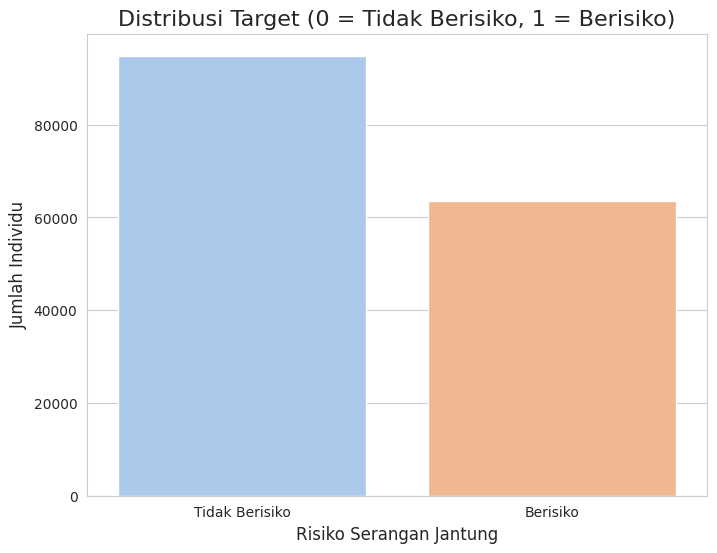

Visualisasi distribusi target ditampilkan.


In [6]:
print("\nBagian 3: Eksplorasi Data (EDA)")
print("-----------------------------------------")

# Visualisasi 1: Distribusi variabel target 'heart_attack'
plt.figure(figsize=(8, 6))
sns.countplot(x='heart_attack', data=df, palette='pastel')
plt.title('Distribusi Target (0 = Tidak Berisiko, 1 = Berisiko)', fontsize=16)
plt.xlabel('Risiko Serangan Jantung', fontsize=12)
plt.ylabel('Jumlah Individu', fontsize=12)
plt.xticks([0, 1], ['Tidak Berisiko', 'Berisiko'])
plt.show()

print("Visualisasi distribusi target ditampilkan.")

**📊 Interpretasi Distribusi Target**

Grafik menunjukkan bahwa terdapat sekitar 95.000 individu yang tidak berisiko dan 63.000 individu yang berisiko terkena serangan jantung.

### BAGIAN 4: PERSIAPAN DATA (PREPROCESSING)

Pada tahap ini, data disiapkan agar dapat digunakan oleh model machine learning. Proses dimulai dengan memisahkan fitur dan target, mengidentifikasi tipe data (numerik dan kategorikal), serta menerapkan teknik preprocessing yang sesuai. Fitur numerik akan diseragamkan menggunakan **StandardScaler**, sedangkan fitur kategorikal diubah menjadi representasi numerik dengan **OneHotEncoder**. Terakhir, data dibagi menjadi data latih dan data uji dengan proporsi 80:20 agar model dapat dievaluasi secara adil.

In [7]:
print("\nBagian 4: Persiapan Data (Preprocessing)")
print("-----------------------------------------")

# 1. Memisahkan fitur (X) dan target (y)
X = df.drop('heart_attack', axis=1)
y = df['heart_attack']

# 2. Mengidentifikasi tipe kolom
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"Ditemukan {len(numerical_features)} fitur numerik dan {len(categorical_features)} fitur kategorikal.")

# 3. Membuat preprocessor menggunakan ColumnTransformer
#    - Fitur numerik akan di-scaling (nilainya diseragamkan).
#    - Fitur kategorikal akan di-encode (diubah menjadi angka).
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Membagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data berhasil dibagi: {X_train.shape[0]} baris untuk pelatihan, {X_test.shape[0]} baris untuk pengujian.")


Bagian 4: Persiapan Data (Preprocessing)
-----------------------------------------
Ditemukan 17 fitur numerik dan 10 fitur kategorikal.
Data berhasil dibagi: 126684 baris untuk pelatihan, 31671 baris untuk pengujian.


### BAGIAN 5: PEMODELAN (MEMBUAT DAN MELATIH MODEL)

Pada tahap ini, dilakukan pembuatan dan pelatihan model klasifikasi menggunakan algoritma **Random Forest**. Proses diawali dengan membentuk sebuah pipeline yang menggabungkan tahap preprocessing dan model ke dalam satu alur kerja yang efisien. Dengan pendekatan ini, seluruh proses transformasi data dan pelatihan model dilakukan secara terintegrasi, sehingga meminimalkan risiko kesalahan dan meningkatkan reusabilitas model.

In [8]:
print("\nBagian 5: Pemodelan")
print("-----------------------------------------")

# Membuat pipeline yang menyatukan preprocessor dan classifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1, class_weight='balanced'))
])

# Melatih pipeline dengan data pelatihan
print("Memulai pelatihan model Random Forest...")
model_pipeline.fit(X_train, y_train)
print("Model berhasil dilatih!")



Bagian 5: Pemodelan
-----------------------------------------
Memulai pelatihan model Random Forest...
Model berhasil dilatih!


### BAGIAN 6: EVALUASI KINERJA MODEL

Setelah model dilatih, tahap selanjutnya adalah mengevaluasi performanya. Evaluasi dilakukan menggunakan data uji yang sebelumnya dipisahkan. Beberapa metrik yang digunakan meliputi **akurasi**, **precision**, **recall**, dan **f1-score**. Metrik-metrik ini membantu menilai seberapa baik model dalam mengklasifikasikan individu yang berisiko maupun tidak berisiko terkena serangan jantung.

In [9]:
print("\nBagian 6: Evaluasi Kinerja Model")
print("-----------------------------------------")

# Membuat prediksi pada data uji
y_pred = model_pipeline.predict(X_test)

# Menampilkan laporan klasifikasi
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=['Tidak Berisiko', 'Berisiko']))

# Menampilkan akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")


Bagian 6: Evaluasi Kinerja Model
-----------------------------------------
Laporan Klasifikasi:
                precision    recall  f1-score   support

Tidak Berisiko       0.80      0.73      0.76     18971
      Berisiko       0.64      0.72      0.68     12700

      accuracy                           0.73     31671
     macro avg       0.72      0.73      0.72     31671
  weighted avg       0.73      0.73      0.73     31671

Akurasi Model: 72.60%


**📊 Interpretasi Distribusi Target**

Terdapat 18.971 individu Tidak Berisiko dan 12.700 individu Berisiko terkena serangan jantung. Distribusi ini menunjukkan adanya ketidakseimbangan kelas, di mana kelas "Tidak Berisiko" lebih dominan, sehingga dapat memengaruhi akurasi model dalam mengenali kasus "Berisiko".

### BAGIAN 7: VISUALISASI HASIL EVALUASI

Visualisasi digunakan untuk memahami lebih dalam bagaimana performa model dan bagaimana kontribusi fitur terhadap prediksi. Beberapa visual yang disajikan meliputi:

- **Confusion Matrix** untuk melihat jumlah prediksi benar dan salah.
- **Feature Importance** untuk mengidentifikasi fitur-fitur yang paling berpengaruh dalam prediksi.
- **Kurva ROC** untuk menilai kemampuan model dalam membedakan antara kelas.

Visualisasi ini membantu dalam mengevaluasi kekuatan dan keterbatasan model secara intuitif.


Bagian 7: Visualisasi Hasil Evaluasi
-----------------------------------------


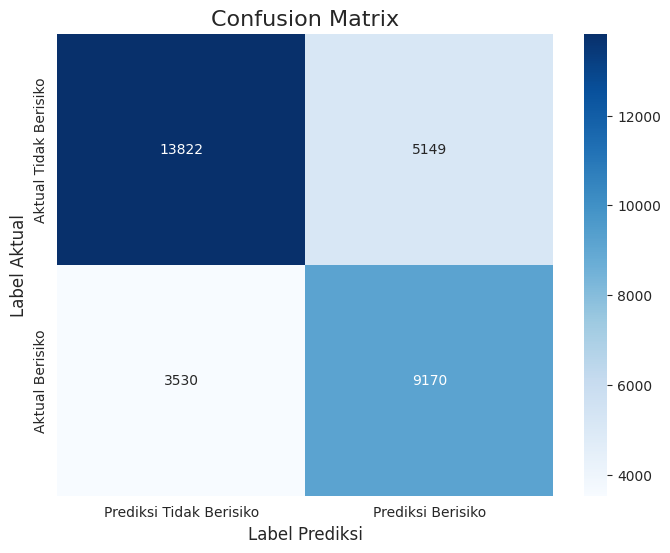

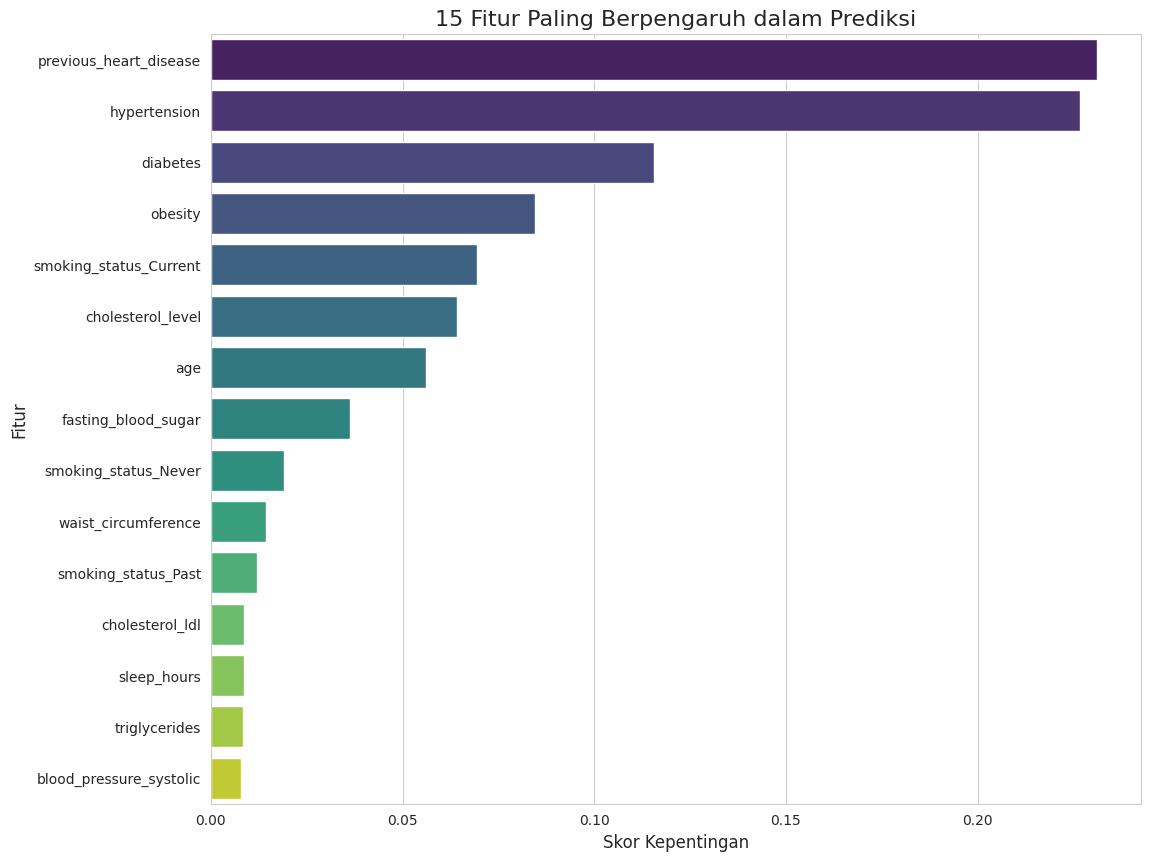

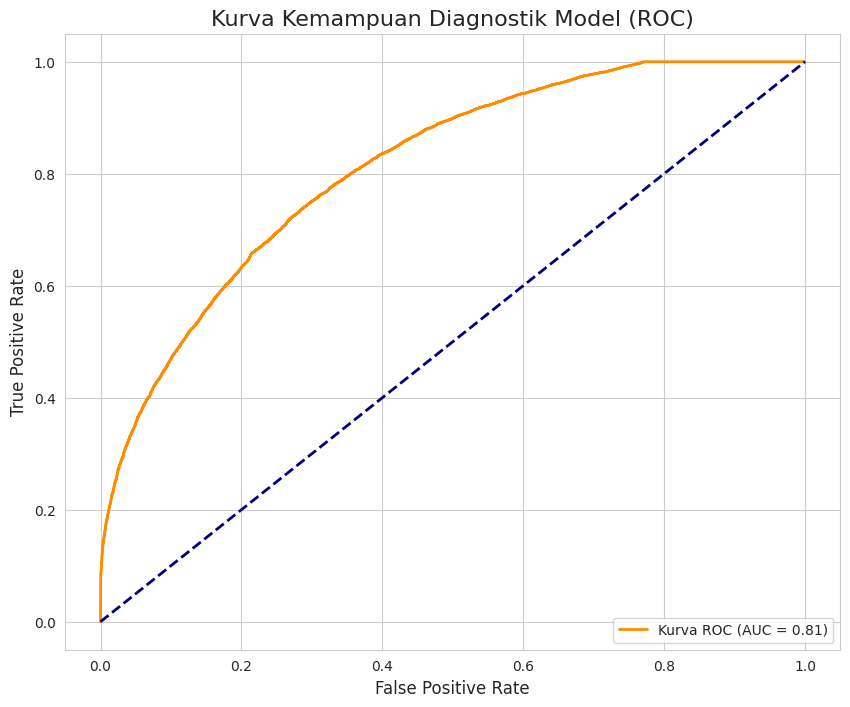

In [10]:
print("\nBagian 7: Visualisasi Hasil Evaluasi")
print("-----------------------------------------")

# Visualisasi 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Tidak Berisiko', 'Prediksi Berisiko'],
            yticklabels=['Aktual Tidak Berisiko', 'Aktual Berisiko'])
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Label Aktual', fontsize=12)
plt.xlabel('Label Prediksi', fontsize=12)
plt.show()

# Visualisasi 2: Tingkat Kepentingan Fitur
ohe_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + ohe_feature_names.tolist()
importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_importances = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 10))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('15 Fitur Paling Berpengaruh dalam Prediksi', fontsize=16)
plt.xlabel('Skor Kepentingan', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.show()

# Visualisasi 3: Kurva ROC
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Kurva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Kurva Kemampuan Diagnostik Model (ROC)', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right")
plt.show()

**📊 Interpretasi Analisis Deskriptif Faktor Risiko**

Model Random Forest berhasil mengidentifikasi faktor-faktor utama yang berkontribusi terhadap risiko serangan jantung. Berdasarkan interpretasi fitur, faktor-faktor tersebut dikelompokkan menjadi tiga kategori utama:

Berikut adalah analisis deskriptif dari faktor-faktor utama yang diidentifikasi oleh model:

1. **Faktor Kondisi Medis yang Sudah Ada**
*Kategori ini secara konsisten menjadi prediktor paling kuat, menegaskan bahwa riwayat kesehatan pasien adalah dasar utama dalam menentukan risiko di masa depan.*

* **Riwayat Penyakit Jantung Sebelumnya (`previous_heart_disease`)**
    > Faktor ini adalah penanda risiko paling dominan. Model dengan jelas mempelajari bahwa jika sistem kardiovaskular seseorang sudah pernah terganggu, probabilitas untuk masalah berulang meningkat secara eksponensial. Ini adalah sinyal terkuat bagi model.

* **Hipertensi (`hypertension`) & Diabetes (`diabetes`)**
    > Kedua kondisi kronis ini berada di urutan teratas. Model mengidentifikasi status hipertensi dan diabetes sebagai "sinyal bahaya" yang sangat kuat, karena keduanya secara langsung merusak sistem peredaran darah dan memaksa jantung bekerja lebih keras.


2. **Faktor Gaya Hidup dan Perilaku**
*Pilihan gaya hidup sehari-hari terbukti memiliki dampak besar. Kategori ini penting karena faktor-faktor di dalamnya dapat diubah untuk menurunkan risiko.*

* **Obesitas (`obesity`)**
    > Ditemukan sebagai faktor gaya hidup paling berpengaruh. Model melihatnya bukan sekadar berat badan, tetapi sebagai pemicu kondisi lain seperti hipertensi dan diabetes, yang menjadikannya faktor risiko sentral.

* **Status Merokok (`smoking_status`)**
    > Model secara cerdas membedakan status merokok. Status sebagai **perokok aktif (`Current`)** menjadi penanda risiko tinggi. Namun, status **tidak pernah merokok (`Never`)** dan **mantan perokok (`Past`)** juga memberikan informasi penting bagi model untuk membedakan tingkat risiko antar individu.


3. **Faktor Angka-Angka Klinis Spesifik**
*Kategori ini mencakup penanda biologis terukur yang memberikan gambaran kondisi metabolik dan kardiovaskular pasien saat ini.*

* **Pengukuran Klinis Utama**
    > Variabel seperti `cholesterol_level`, `age`, `fasting_blood_sugar`, dan `waist_circumference` memegang peranan penting. Ini menunjukkan bahwa model sangat bergantung pada angka-angka kuantitatif ini untuk membuat keputusan prediktifnya.

* **Detail Pengukuran Lainnya**
    > Angka yang lebih spesifik seperti `cholesterol_ldl`, `triglycerides`, dan `blood_pressure_systolic` juga masuk dalam 15 besar. Ini menunjukkan kemampuan model dalam menangkap nuansa yang lebih halus dalam data klinis.

* **Temuan Menarik: Jam Tidur (`sleep_hours`)**
    > Masuknya durasi tidur dalam daftar ini mendukung bukti medis modern bahwa kualitas istirahat yang buruk adalah faktor risiko yang tidak boleh diabaikan untuk kesehatan jantung.

---

## Kesimpulan Akhir

Model klasifikasi Random Forest menunjukkan kinerja yang menjanjikan dalam membedakan individu yang berisiko dan tidak berisiko mengalami serangan jantung, dengan tingkat akurasi mencapai 72,6%. Meskipun data yang digunakan memiliki ketidakseimbangan kelas, model mampu mempertahankan precision dan recall yang seimbang, menunjukkan keandalannya dalam pengambilan keputusan prediktif.

Hasil analisis menyoroti bahwa prediksi risiko serangan jantung tidak ditentukan oleh satu faktor tunggal, melainkan merupakan hasil dari interaksi kompleks antara riwayat medis, gaya hidup, dan kondisi biologis saat ini sebuah prinsip yang dapat dirangkum sebagai:

1. Risiko serangan jantung merupakan hasil akumulasi dari berbagai faktor yang saling memengaruhi. Interaksi antara riwayat penyakit, kebiasaan hidup, dan kondisi fisik saat ini menentukan tingkat kerentanan seseorang.
2. Faktor-faktor seperti hipertensi, diabetes, dan riwayat penyakit jantung terbukti sebagai dasar utama yang secara signifikan memengaruhi prediksi risiko. Kondisi-kondisi ini membentuk landasan biologis terhadap kerentanan kardiovaskular.
3. Merokok, kurangnya aktivitas fisik, serta obesitas berperan sebagai akselerator risiko, yang dapat memperburuk kondisi medis yang sudah ada. Faktor-faktor gaya hidup ini mempercepat timbulnya komplikasi dan meningkatkan beban risiko keseluruhan.

---

> ⚠️ **Penting**: Analisis ini sepenuhnya didasarkan pada apa yang dianggap penting oleh model *machine learning* untuk membuat prediksi. Hasil ini harus dilihat sebagai wawasan dari data dan **bukan merupakan nasihat medis**. Untuk evaluasi risiko kesehatan yang akurat dan personal, konsultasi dengan dokter atau tenaga medis profesional adalah langkah yang wajib dilakukan.